In [2]:
# Read data and initial pandas summary

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "train_20240206.csv"

df = pd.read_csv(DATA_PATH)
print("--- df.info() ---")
print(df.info())

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             999 non-null    int64  
 1   MSSubClass     999 non-null    int64  
 2   MSZoning       999 non-null    object 
 3   LotFrontage    826 non-null    float64
 4   LotArea        999 non-null    int64  
 5   Street         999 non-null    object 
 6   Alley          65 non-null     object 
 7   LotShape       999 non-null    object 
 8   LandContour    999 non-null    object 
 9   Utilities      999 non-null    object 
 10  LotConfig      999 non-null    object 
 11  LandSlope      999 non-null    object 
 12  Neighborhood   999 non-null    object 
 13  Condition1     999 non-null    object 
 14  Condition2     999 non-null    object 
 15  BldgType       999 non-null    object 
 16  HouseStyle     999 non-null    object 
 17  OverallQual    999 non-null    int64

In [3]:
# Data Quality Report for numerical features
# Choosing numerical predictors for KNN

print("\n--- Data Quality Report ---")
numerical_cols = df.select_dtypes(include=["int64", "float64"])

num_report = numerical_cols.describe().T
num_report['% Miss'] = numerical_cols.isna().mean()*100
num_report['Card.'] = numerical_cols.nunique()
num_report = num_report.rename(columns={
    'count': 'Count',
    'min': 'Min',
    'mean': 'Mean',
    'max': 'Max',
    '50%': 'Median',
    '25%': 'Q1',
    '75%': 'Q3',
    'std': 'Std. Dev'
})

num_report = num_report[['Count', '% Miss', 'Card.', 'Min', 'Q1', 'Mean', 'Median', 'Q3', 'Max', 'Std. Dev']]
print("Numerical Data Quality Report:")
display(num_report)

print("\n--- Chosen Features: ---")
num_features = ['LotFrontage', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'SalePrice']
print("Numerical Features:", num_features)

print(df[num_features])


--- Data Quality Report ---
Numerical Data Quality Report:


,Count,% Miss,Card.,Min,Q1,Mean,Median,Q3,Max,Std. Dev
Id,999.0,0.000000,999,1.0,250.5,500.000000,500.0,749.5,999.0,288.530761
MSSubClass,999.0,0.000000,15,20.0,20.0,56.916917,50.0,70.0,190.0,42.261403
LotFrontage,826.0,17.317317,102,21.0,60.0,69.962470,70.0,80.0,313.0,23.215821
LotArea,999.0,0.000000,780,1300.0,7589.0,10695.109109,9452.0,11632.0,215245.0,11417.706546
OverallQual,999.0,0.000000,10,1.0,5.0,6.124124,6.0,7.0,10.0,1.383632
OverallCond,999.0,0.000000,9,1.0,5.0,5.587588,5.0,6.0,9.0,1.109300
YearBuilt,999.0,0.000000,107,1880.0,1954.0,1971.598599,1974.0,2000.0,2010.0,30.003240
YearRemodAdd,999.0,0.000000,61,1950.0,1967.0,1985.258258,1994.0,2004.0,2010.0,20.411974
MasVnrArea,993.0,0.600601,267,0.0,0.0,109.311178,0.0,175.0,1600.0,188.961644
BsmtFinSF1,999.0,0.000000,500,0.0,0.0,444.972973,384.0,726.0,2260.0,442.550816



--- Chosen Features: ---
Numerical Features: ['LotFrontage', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'SalePrice']
     LotFrontage  YearBuilt  TotalBsmtSF  1stFlrSF  GarageArea  SalePrice
0           65.0       2003          856       856         548     208500
1           80.0       1976         1262      1262         460     181500
2           68.0       2001          920       920         608     223500
3           60.0       1915          756       961         642     140000
4           84.0       2000         1145      1145         836     250000
..           ...        ...          ...       ...         ...        ...
994         96.0       2006         1700      1718         786     337500
995         51.0       1946          747       774         305     121600
996          NaN       1961         1050      1050         368     136500
997          NaN       1970         1442      1442         615     185000
998         60.0       1922         1007      1077       

In [4]:
# Data Quality Report for categorical features
# Choosing categorical predictors for KNN

categorical_cols = df.select_dtypes(include=["object"])
cat_report = pd.DataFrame({
    'Feature': categorical_cols.columns,
    'Count': categorical_cols.count(),
    '% Miss': categorical_cols.isna().mean()*100,
    'Card.': categorical_cols.nunique(),
    'Mode': [categorical_cols[c].value_counts().index[0] for c in categorical_cols.columns],
    'Mode Freq': [categorical_cols[c].value_counts().iloc[0] for c in categorical_cols.columns],
    'Mode %': [categorical_cols[c].value_counts().iloc[0] / categorical_cols[c].count()*100 for c in categorical_cols.columns],
    '2nd Mode': [categorical_cols[c].value_counts().index[1] for c in categorical_cols.columns],
    '2nd Mode Freq': [categorical_cols[c].value_counts().iloc[1] for c in categorical_cols.columns],
    '2nd Mode %': [categorical_cols[c].value_counts().iloc[1] / categorical_cols[c].count()*100 for c in categorical_cols.columns]
})

print("\nCategorical Data Quality Report:")
display(cat_report)

print("\n--- Chosen Features: ---")
cat_features = ['Neighborhood', 'LotConfig', 'GarageType']
print("Categorical Features:", cat_features)
print(df[cat_features])


Categorical Data Quality Report:


,Feature,Count,% Miss,Card.,Mode,Mode Freq,Mode %,2nd Mode,2nd Mode Freq,2nd Mode %
MSZoning,MSZoning,999,0.000000,5,RL,780,78.078078,RM,150,15.015015
Street,Street,999,0.000000,2,Pave,995,99.599600,Grvl,4,0.400400
Alley,Alley,65,93.493493,2,Grvl,35,53.846154,Pave,30,46.153846
LotShape,LotShape,999,0.000000,4,Reg,622,62.262262,IR1,341,34.134134
LandContour,LandContour,999,0.000000,4,Lvl,898,89.889890,Bnk,39,3.903904
Utilities,Utilities,999,0.000000,2,AllPub,998,99.899900,NoSeWa,1,0.100100
LotConfig,LotConfig,999,0.000000,5,Inside,715,71.571572,Corner,186,18.618619
LandSlope,LandSlope,999,0.000000,3,Gtl,944,94.494494,Mod,44,4.404404
Neighborhood,Neighborhood,999,0.000000,25,NAmes,152,15.215215,CollgCr,100,10.010010
Condition1,Condition1,999,0.000000,9,Norm,861,86.186186,Feedr,54,5.405405



--- Chosen Features: ---
Categorical Features: ['Neighborhood', 'LotConfig', 'GarageType']
    Neighborhood LotConfig GarageType
0        CollgCr    Inside     Attchd
1        Veenker       FR2     Attchd
2        CollgCr    Inside     Attchd
3        Crawfor    Corner     Detchd
4        NoRidge       FR2     Attchd
..           ...       ...        ...
994      NridgHt       FR2     Attchd
995      BrkSide    Inside     Detchd
996        NAmes    Inside     Attchd
997       NWAmes    Inside     Attchd
998       IDOTRR    Inside     Detchd

[999 rows x 3 columns]


In [7]:
# Replacing missing values in numerical features with mean value
lot_frontage_initial_mean = df['LotFrontage'].mean()
print(lot_frontage_initial_mean)

df['LotFrontage'] = df['LotFrontage'].fillna(lot_frontage_initial_mean)
display(df[num_features].isnull().sum())

69.96246973365618


,0
LotFrontage,0
YearBuilt,0
TotalBsmtSF,0
1stFlrSF,0
GarageArea,0
SalePrice,0



--- Data Plots: ---


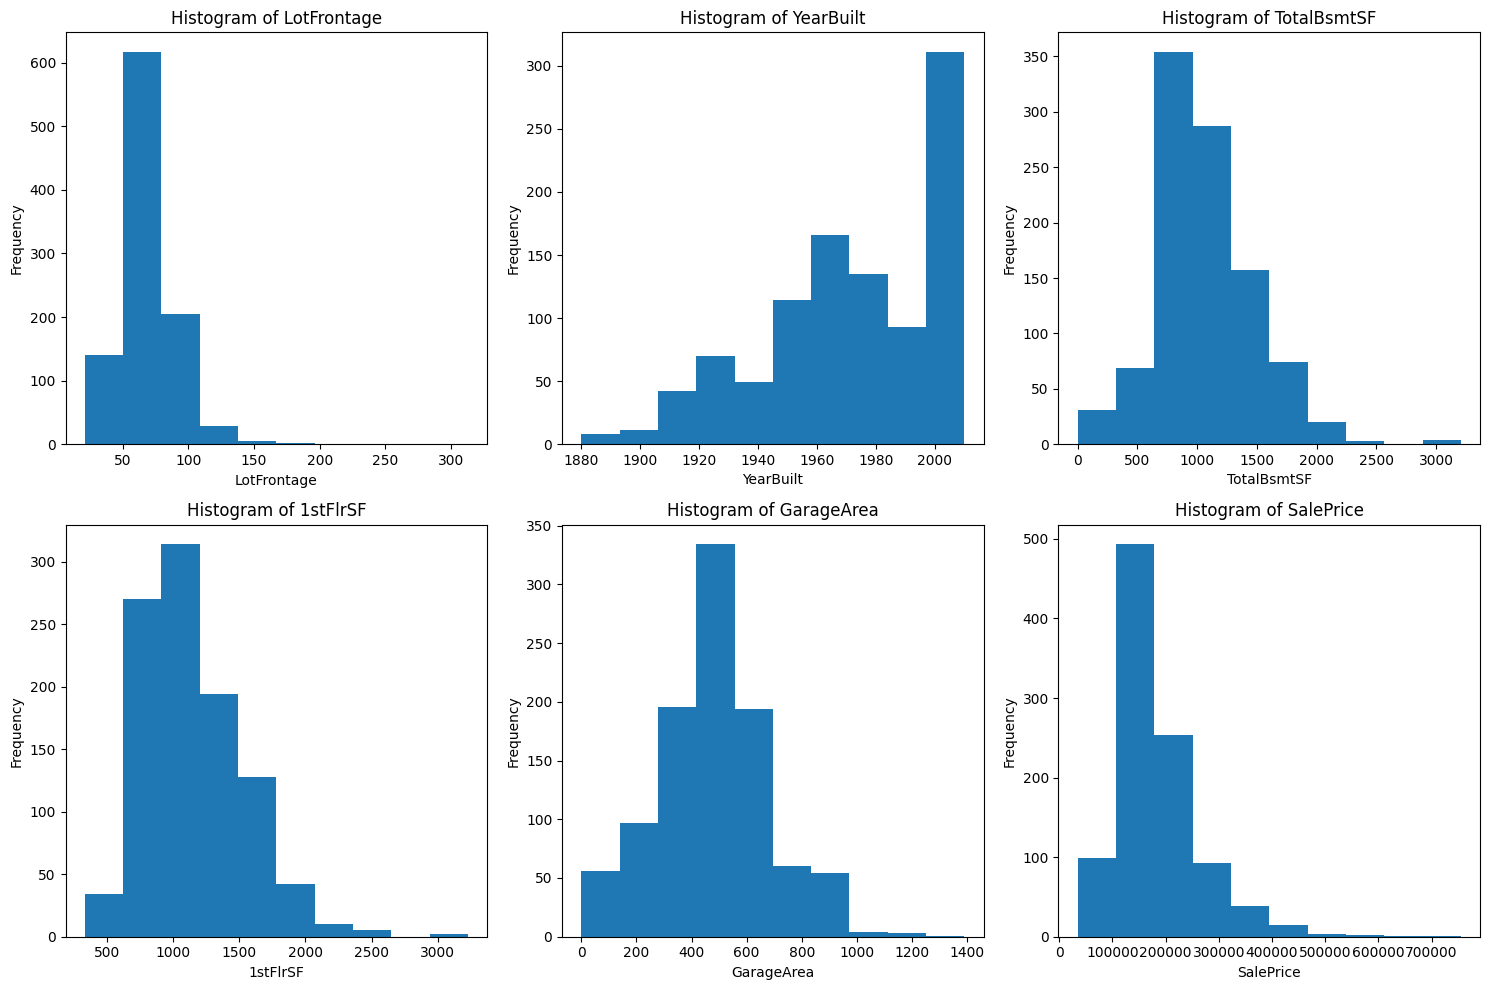

In [8]:
# Plotting histograms for the chosen numerical features

print("\n--- Data Plots: ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col])
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

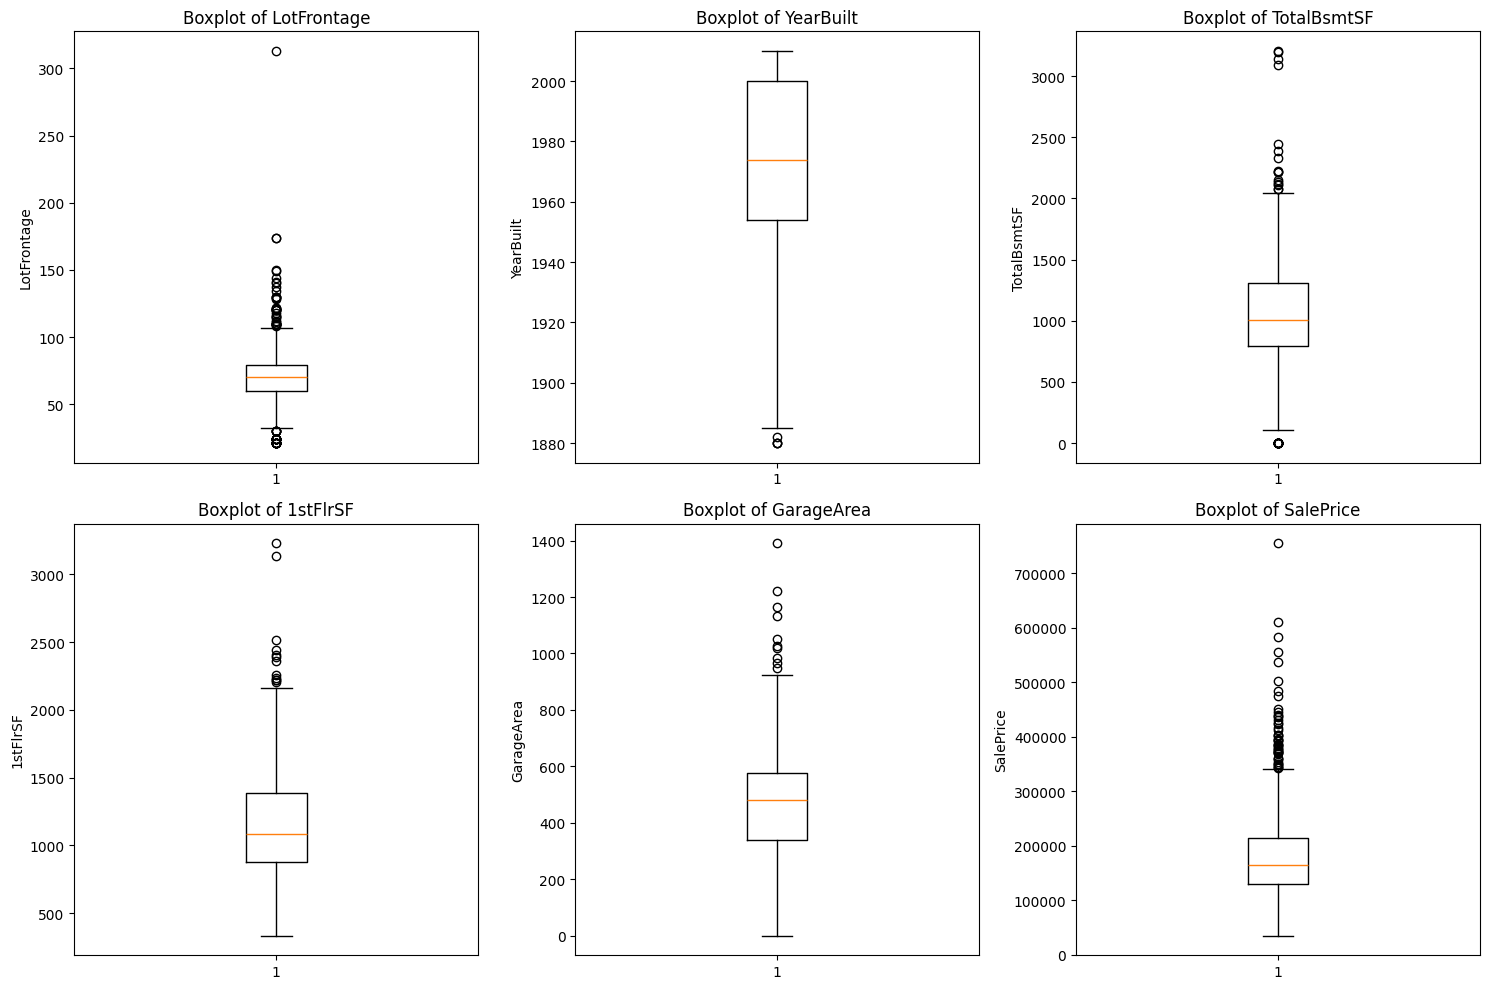

In [9]:
# Plotting boxplots for the chosen numerical features

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[col], vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

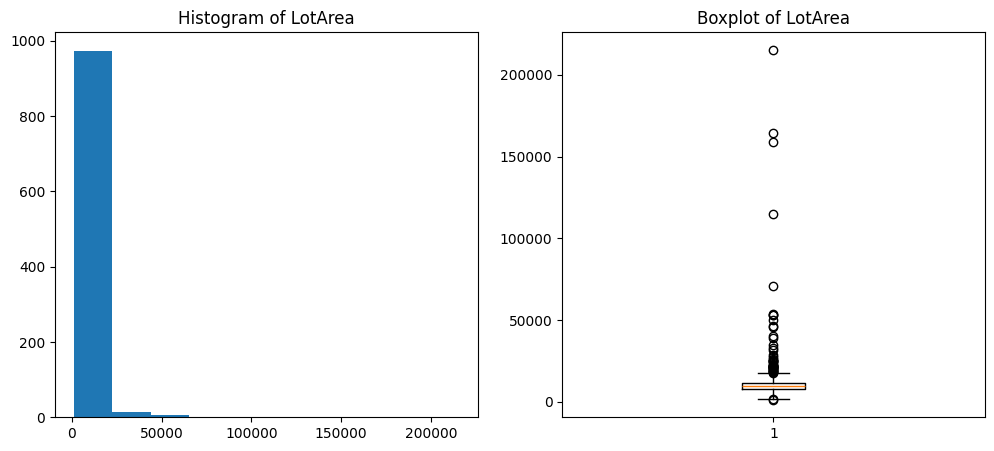

In [10]:
# Plotting histogram and boxplot for the target value - LotArea

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['LotArea'])
plt.title("Histogram of LotArea")

plt.subplot(1,2,2)
plt.boxplot(df['LotArea'], vert=True)
plt.title("Boxplot of LotArea")
plt.show()

In [11]:
# Look for outliers to be removed
# Count number of moderate and extreme outliers

outlier_percentage = {}
extreme_outlier_percentage = {}


for col in num_features + ['LotArea']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_percentage[col] = f"{round(len(outliers) / len(df) * 100, 1)}%"


for col in num_features + ['LotArea']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    extreme_outlier_percentage[col] = f"{round(len(outliers) / len(df) * 100, 1)}%"


print("Significant Outliers:\n", outlier_percentage)
print("\nExtreme Outliers:\n", extreme_outlier_percentage)

Significant Outliers:
 {'LotFrontage': '7.1%', 'YearBuilt': '0.4%', 'TotalBsmtSF': '4.0%', '1stFlrSF': '1.2%', 'GarageArea': '1.0%', 'SalePrice': '4.7%', 'LotArea': '4.6%'}

Extreme Outliers:
 {'LotFrontage': '0.9%', 'YearBuilt': '0.0%', 'TotalBsmtSF': '0.4%', '1stFlrSF': '0.2%', 'GarageArea': '0.1%', 'SalePrice': '0.8%', 'LotArea': '2.4%'}


In [12]:
# Remove rows from dataset with extreme outliers from all numerical features

mask = np.ones(len(df), dtype=bool)

for col in num_features + ['LotArea']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    mask &= df[col].between(lower_bound, upper_bound)  # keep only rows within bounds

# Apply mask to remove extreme outliers
df_clean = df[mask].copy()

print(f"Original rows: {len(df)}, after removing extreme outliers: {len(df_clean)}")

Original rows: 999, after removing extreme outliers: 960



--- Data Plots: ---


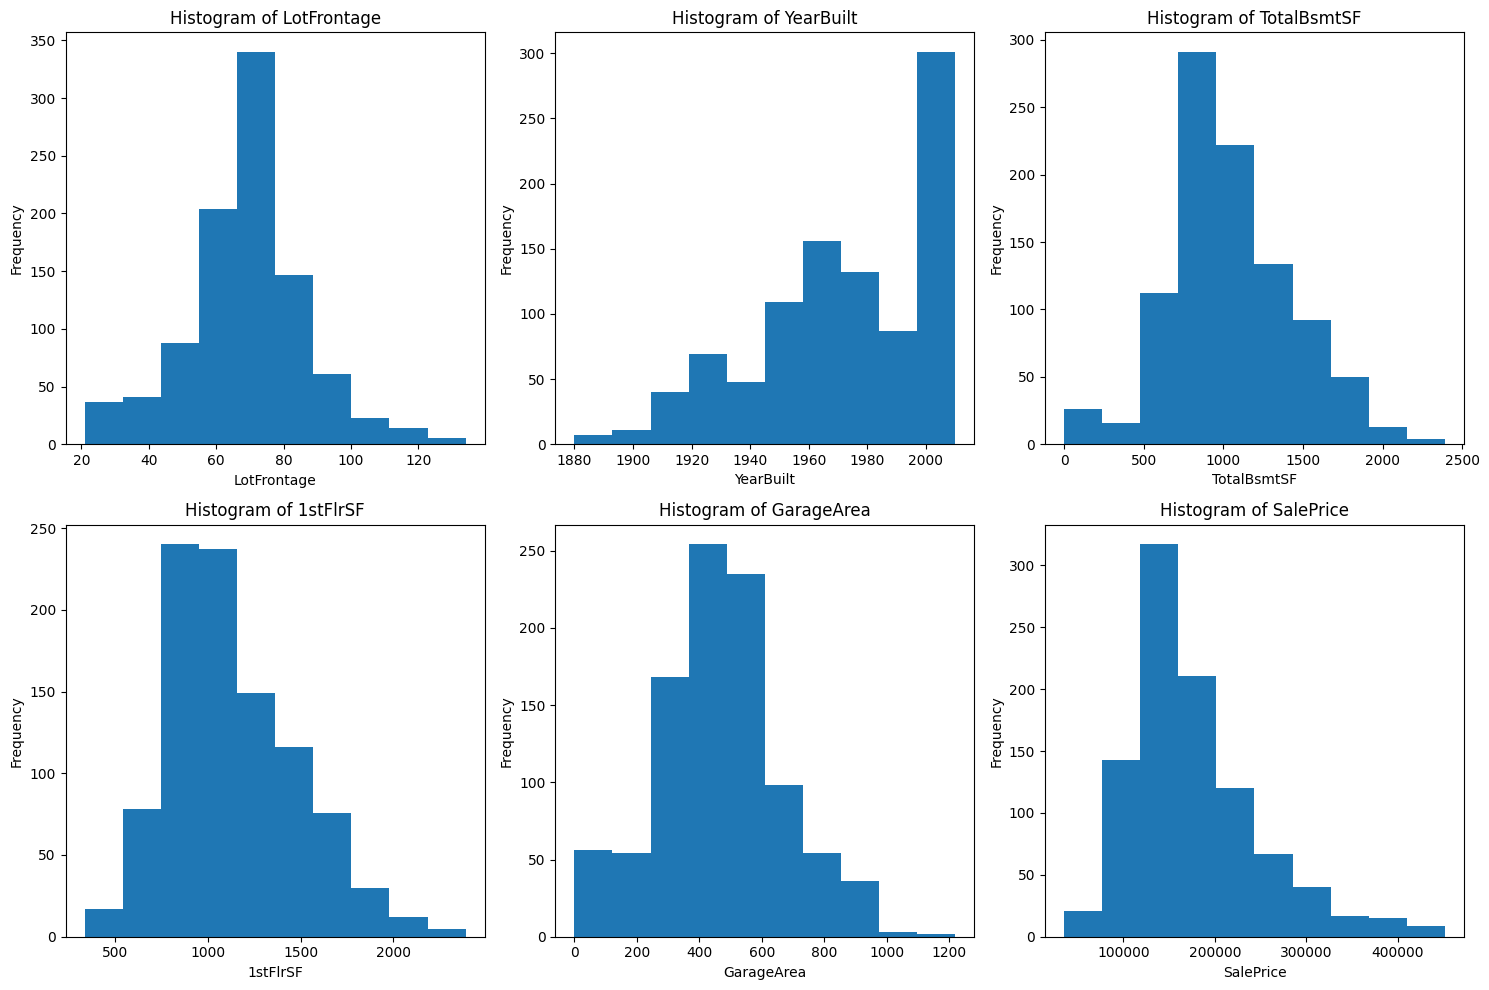

In [13]:
# Plotting histograms after outlier removal

print("\n--- Data Plots: ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    plt.hist(df_clean[col])
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

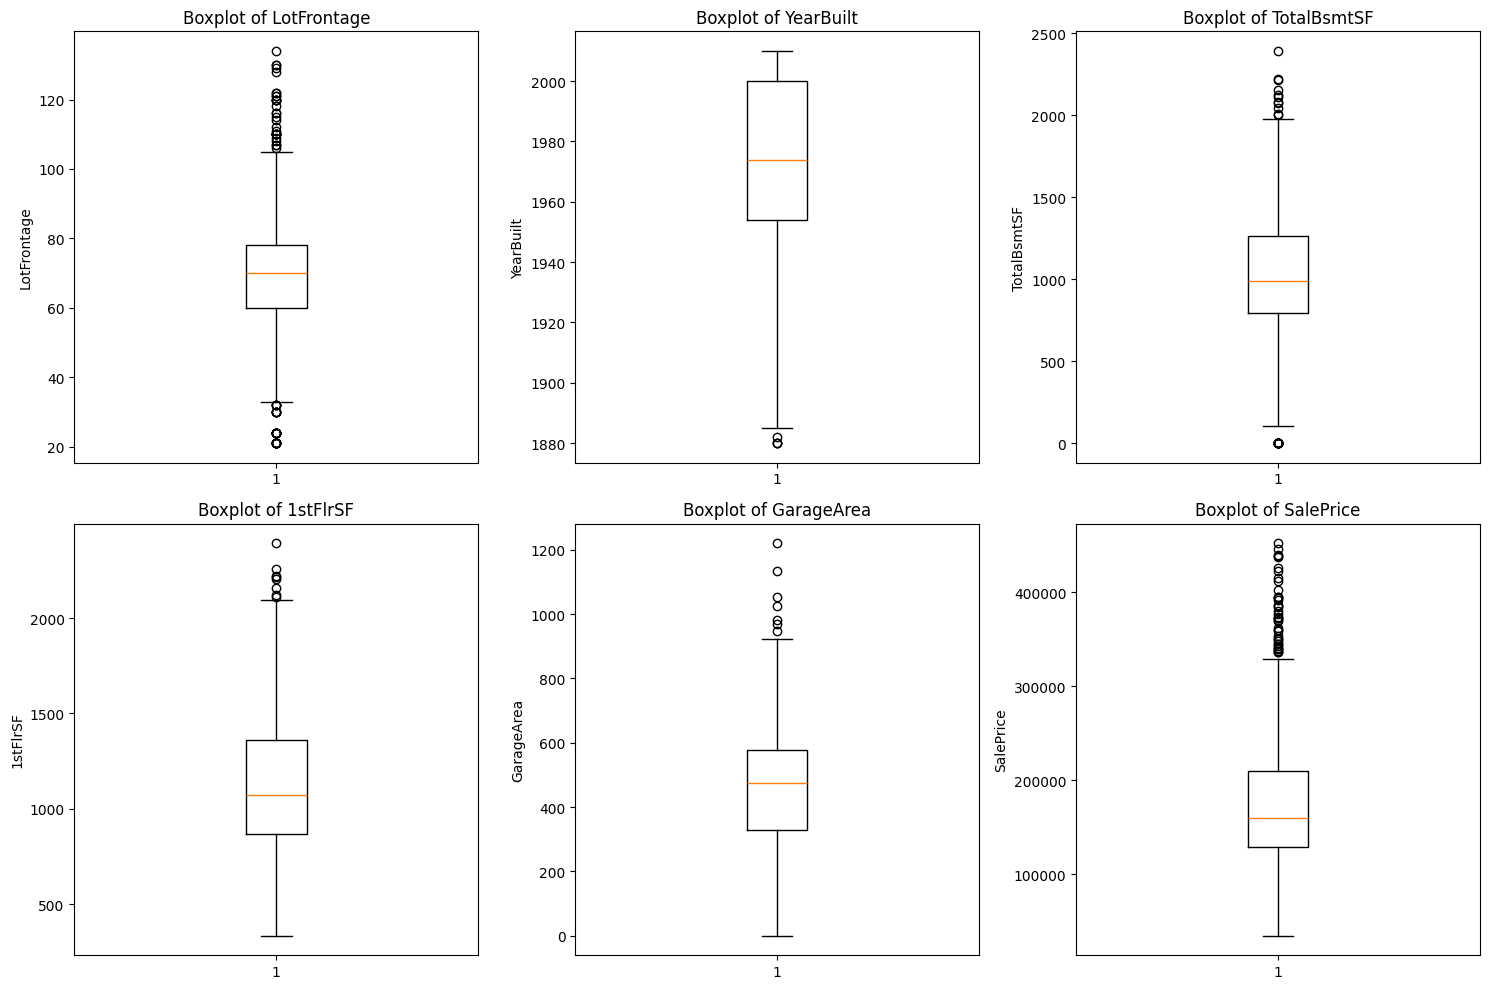

In [14]:
# Plotting boxplots after outlier removal

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_clean[col], vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

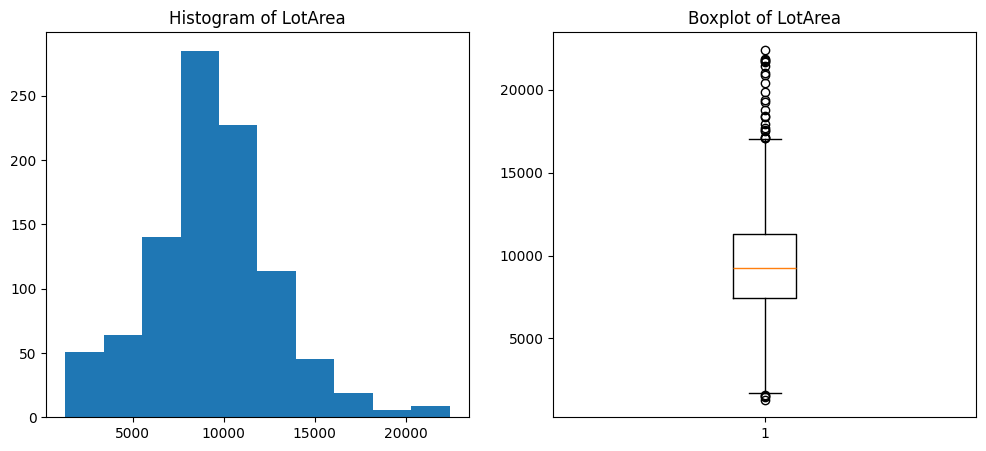

In [15]:
# Plotting histogram and boxplot for LotArea after outlier removal

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_clean['LotArea'])
plt.title("Histogram of LotArea")

plt.subplot(1,2,2)
plt.boxplot(df_clean['LotArea'], vert=True)
plt.title("Boxplot of LotArea")
plt.show()

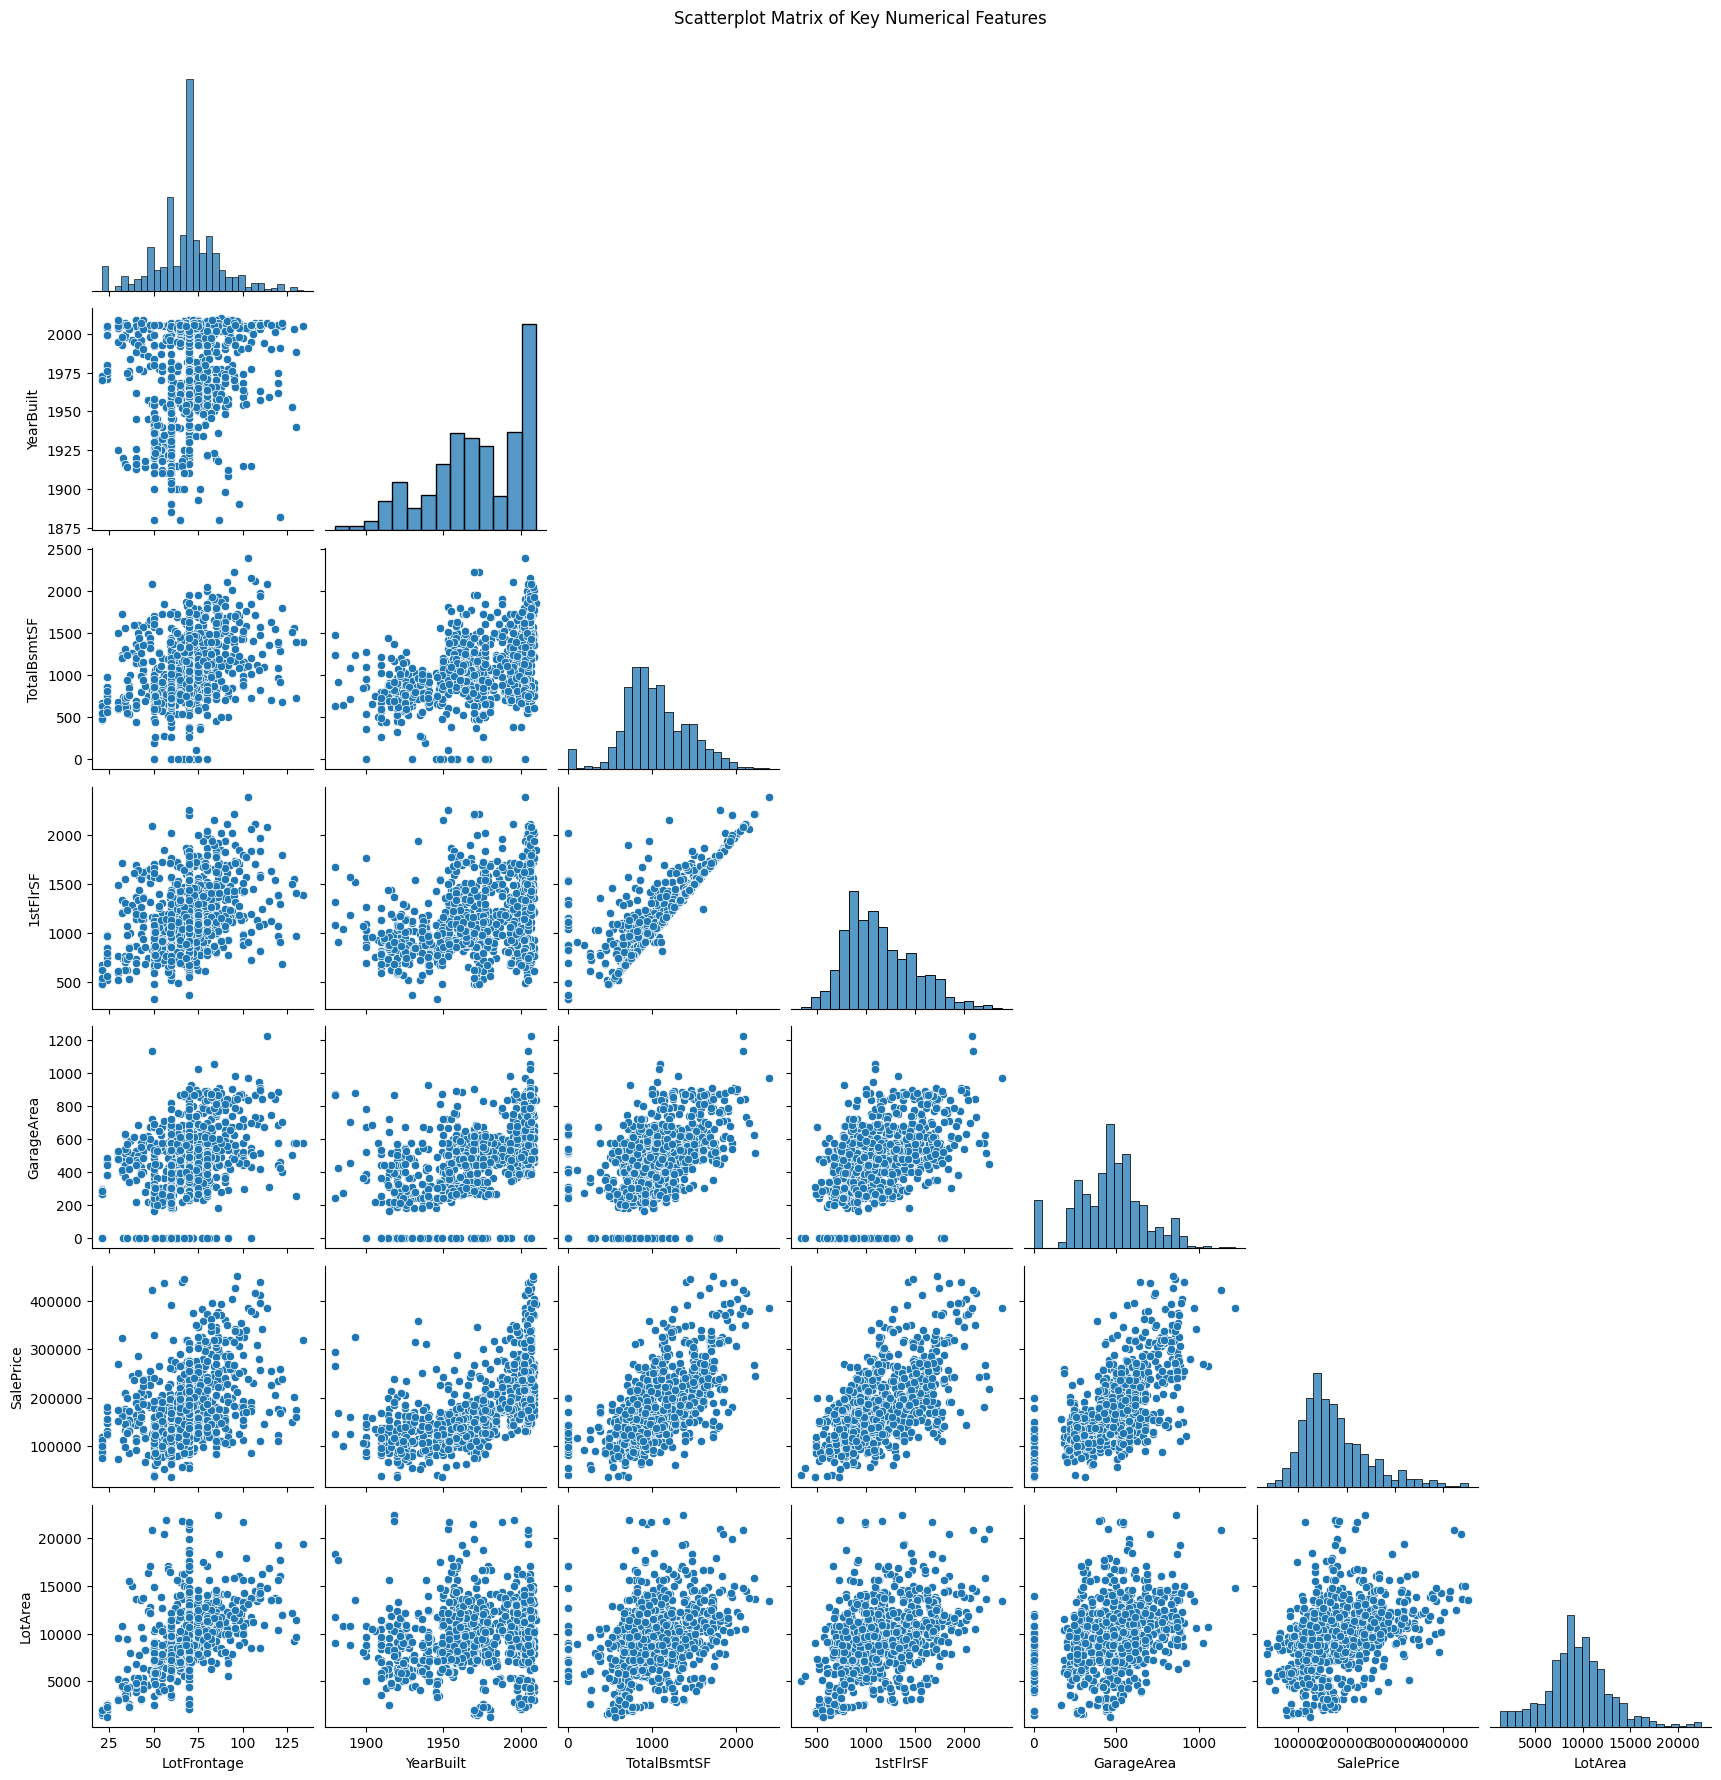

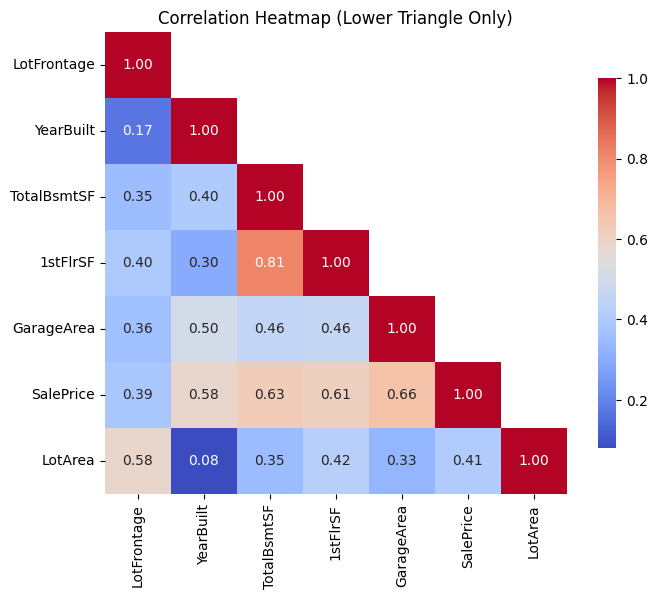

In [16]:
# SPLOM and heatmap

sns.pairplot(
    df_clean[num_features + ['LotArea']],
    corner=True
)
plt.suptitle('Scatterplot Matrix of Key Numerical Features', y=1.02)
plt.show()


corr = df_clean[num_features + ['LotArea']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    mask=mask,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap (Lower Triangle Only)')
plt.show()

In [17]:
# Compute skewness for each column
skewness = df_clean[num_features + ['LotArea']].skew()

# Optional: display nicely
skew_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
}).sort_values(by='Skewness', key=abs, ascending=False)  # sort by absolute skew

print(skew_df)

       Feature  Skewness
5    SalePrice  1.159440
3     1stFlrSF  0.642620
1    YearBuilt -0.619954
6      LotArea  0.358715
2  TotalBsmtSF  0.161566
4   GarageArea -0.067816
0  LotFrontage  0.066997


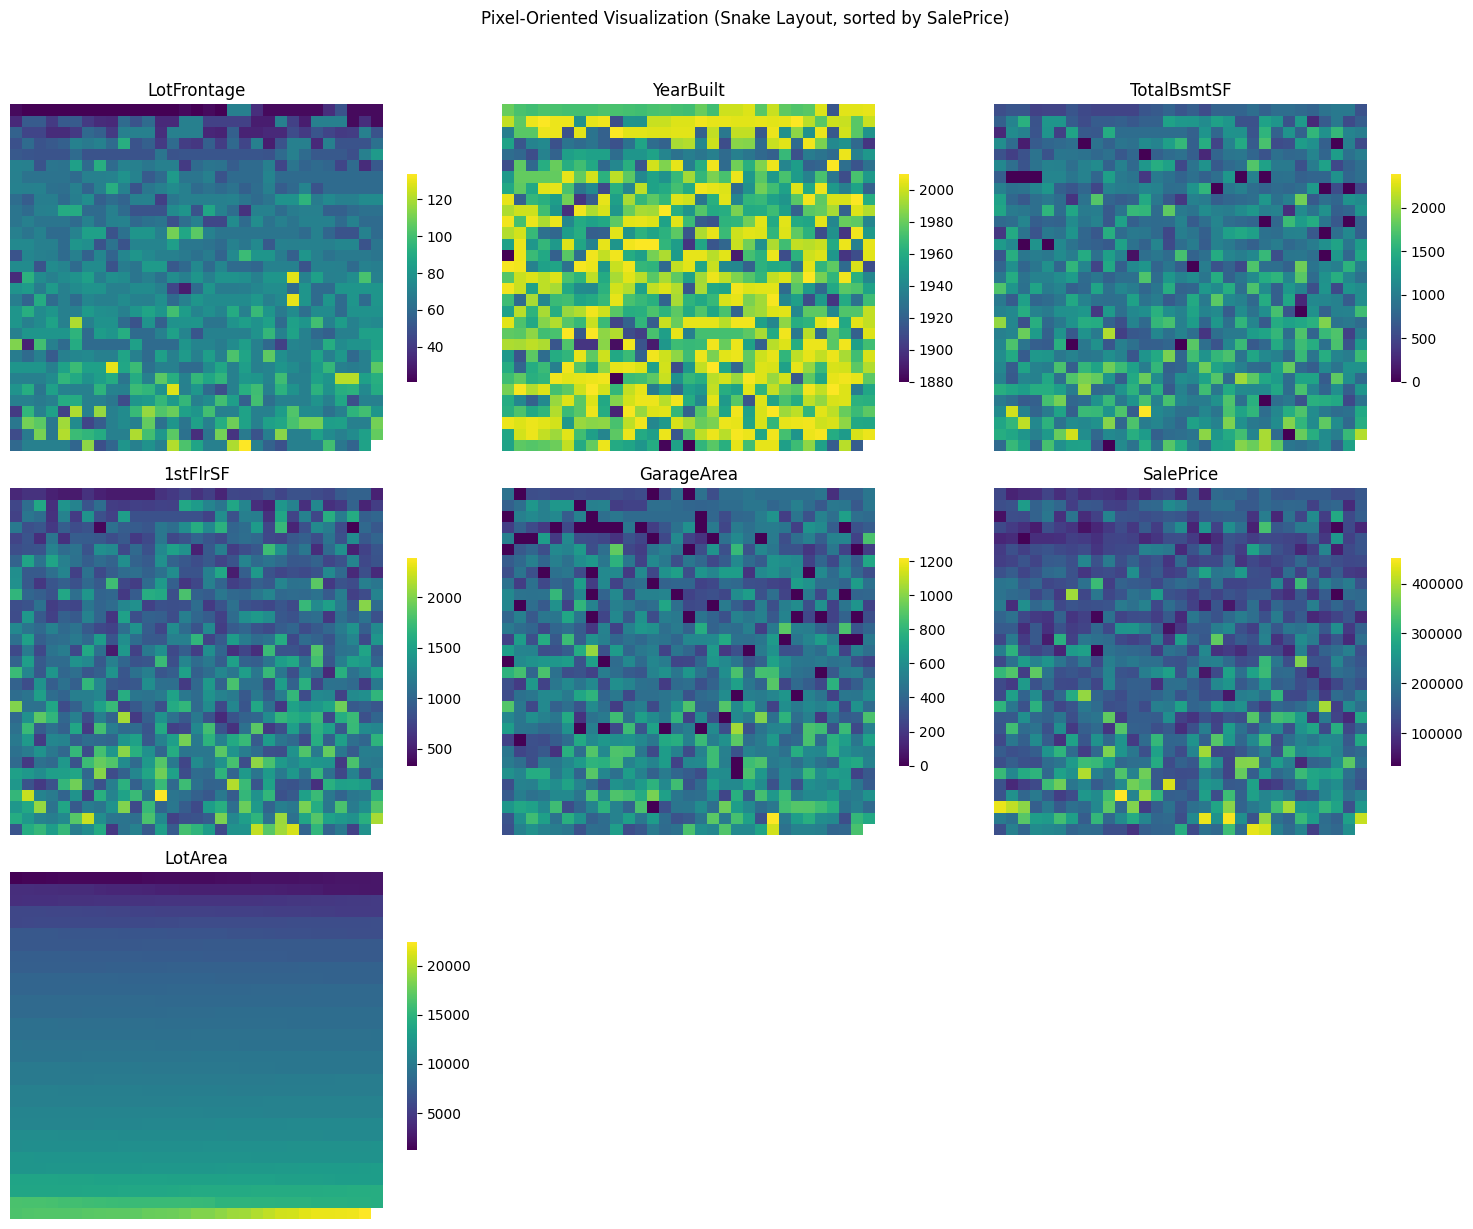

In [18]:
# pixel-oriented + parallel coordinates visualization
import math

df_sorted = df_clean.sort_values(by='LotArea').reset_index(drop=True)
features_to_plot = num_features + ['LotArea']

n_features = len(features_to_plot)
cols_per_row = 3
n_rows_subplots = math.ceil(n_features / cols_per_row)

n_samples = len(df_sorted)

# Determine grid dimensions: aim for ~square grid
grid_cols = math.ceil(math.sqrt(n_samples))
grid_rows = math.ceil(n_samples / grid_cols)

plt.figure(figsize=(5 * cols_per_row, 4 * n_rows_subplots))

for idx, col in enumerate(features_to_plot, 1):
    plt.subplot(n_rows_subplots, cols_per_row, idx)

    values = df_sorted[col].values  # sorted by SalePrice

    # Pad to fill the full grid
    pad_size = grid_rows * grid_cols - n_samples
    padded = np.concatenate([values, np.full(pad_size, np.nan)])

    # Reshape into (grid_rows, grid_cols)
    grid = padded.reshape(grid_rows, grid_cols).copy()

    # Snake pattern: reverse every odd row
    # Row 0 = bottom (left→right), Row 1 (right→left), etc.
    for r in range(1, grid_rows, 2):
        grid[r] = grid[r, ::-1]

    sns.heatmap(
        grid,
        cmap="viridis",
        cbar=True,
        cbar_kws={"shrink": 0.6},
        xticklabels=False,
        yticklabels=False,
        mask=np.isnan(grid)
    )
    plt.title(col)

plt.suptitle("Pixel-Oriented Visualization (Snake Layout, sorted by SalePrice)", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Parallel Coordinates
import plotly.express as px

# Exclude LotArea from the axes — it is the target and is shown via colour instead
predictor_num_features = [f for f in num_features if f != 'LotArea']

mid_point = (df_clean['LotArea'].max() + df_clean['LotArea'].min()) / 2

labels = {col: col for col in predictor_num_features}
labels['LotArea'] = 'Lot Area'

fig = px.parallel_coordinates(
    df_clean[predictor_num_features + ['LotArea']],
    color='LotArea',
    labels=labels,
    color_continuous_scale=px.colors.diverging.Tealrose,
    color_continuous_midpoint=mid_point
)
fig.update_layout(title="Parallel Coordinates Plot of Numerical Predictors (coloured by LotArea)")
fig.show()

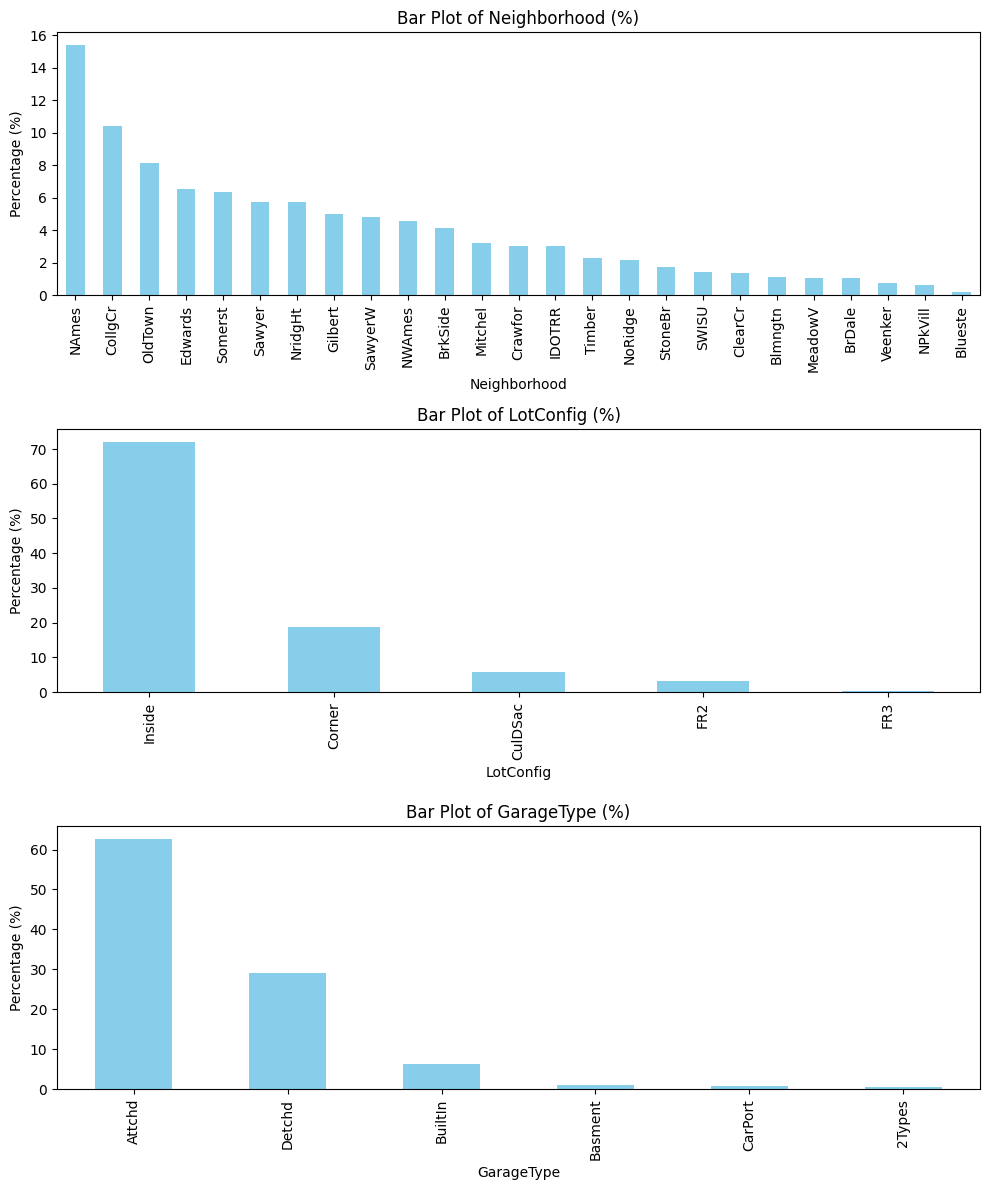

In [20]:
# Bar plots for categorical data

plt.figure(figsize=(10, 12))
for i, col in enumerate(cat_features, 1):
    plt.subplot(len(cat_features), 1, i)

    counts = df_clean[col].value_counts(normalize=True) * 100  # convert to %
    counts.plot(kind='bar', color='skyblue')

    plt.title(f'Bar Plot of {col} (%)')
    plt.ylabel('Percentage (%)')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

/tmp/ipykernel_8956/3135191795.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8956/3135191795.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8956/3135191795.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




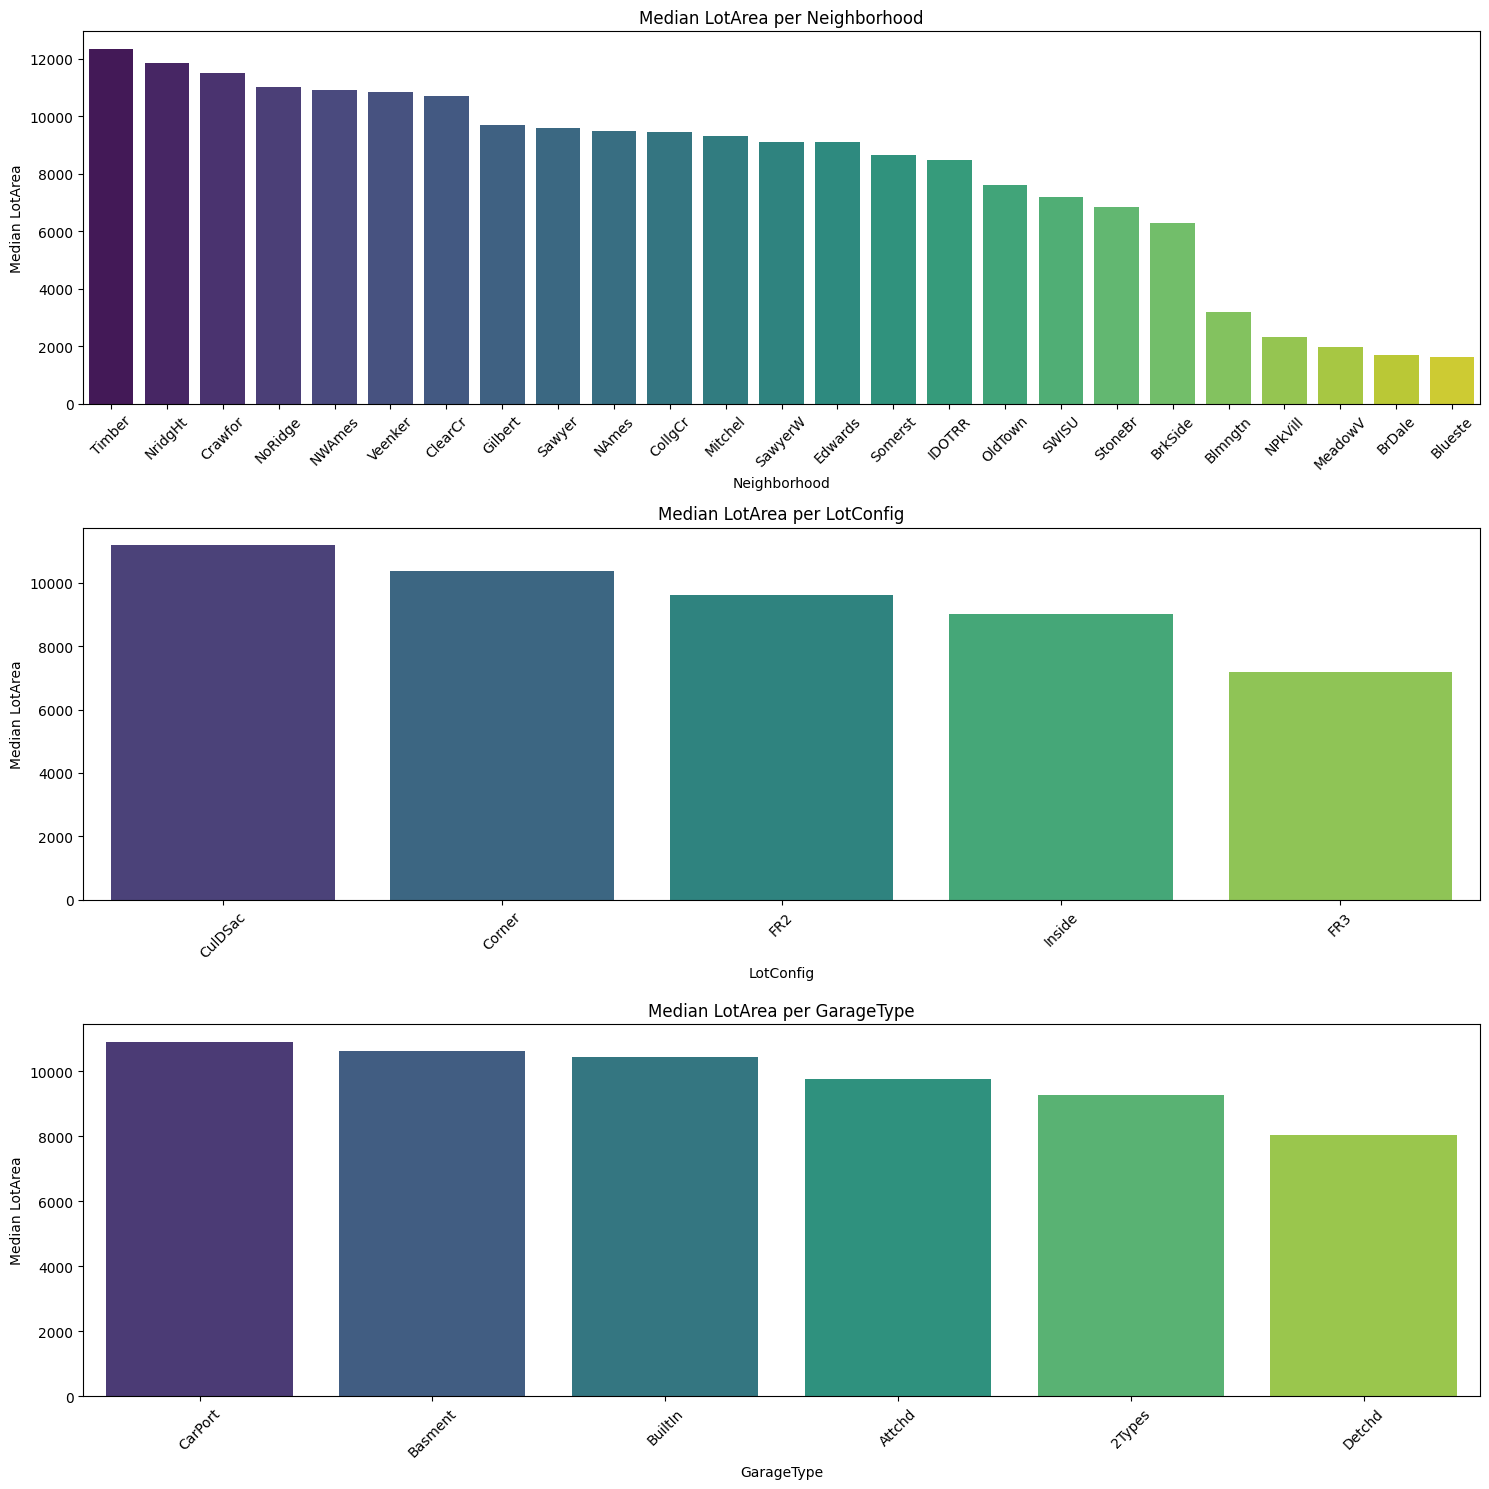

In [21]:
# Replace missing values with mode
# Handle outliers
# Median bar chart

mode_value = df_clean['GarageType'].mode()[0]
df_clean['GarageType'] = df_clean['GarageType'].fillna(mode_value)

plt.figure(figsize=(15, 5 * len(cat_features)))  # Adjust height for number of features

for i, col in enumerate(cat_features, 1):
    plt.subplot(len(cat_features), 1, i)

    # Compute mean LotArea per category
    mean_lotarea = df_clean.groupby(col)['LotArea'].median().sort_values(ascending=False)

    # Bar plot of mean LotArea
    sns.barplot(x=mean_lotarea.index, y=mean_lotarea.values, palette='viridis')

    plt.title(f'Median LotArea per {col}')
    plt.xlabel(col)
    plt.ylabel('Median LotArea')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Alluvial chart (Neighborhood -> LotConfig -> GarageType -> LotArea)
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

# Create binned LotArea
df_clean['LotArea_bin'] = pd.qcut(
    df_clean['LotArea'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

cols = [
    'Neighborhood',
    'LotConfig',
    'GarageType',
    'LotArea_bin'
]

# Count flows between consecutive pairs
flows = []

for i in range(len(cols) - 1):
    grouped = (
        df_clean
        .groupby([cols[i], cols[i+1]])
        .size()
        .reset_index(name='count')
    )
    flows.append(grouped)

# Create unique node list
all_labels = pd.unique(
    pd.concat([df_clean[col] for col in cols], ignore_index=True)
)
label_list = list(all_labels)

label_index = {label: i for i, label in enumerate(label_list)}

sources = []
targets = []
values = []

for flow in flows:
    for _, row in flow.iterrows():
        sources.append(label_index[row[0]])
        targets.append(label_index[row[1]])
        values.append(row['count'])

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=label_list,
        pad=15,
        thickness=20
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(title_text="Alluvial Flow: Neighborhood → LotArea → LotConfig → GarageType")
fig.show()


/tmp/ipykernel_8956/1479034752.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_8956/1479034752.py:46: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_8956/1479034752.py:47: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_8956/1479034752.py:46: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as label

In [23]:
# Search for outlier classes

classes = []
temp = {}
percentages = df_clean['Neighborhood'].value_counts(normalize=True) * 100
for cls, pct in percentages.items():
    temp[cls] = f"{round(pct, 1)}%"
classes.append(temp)
print("Neighborhood:", temp)

temp = {}
percentages = df_clean['LotConfig'].value_counts(normalize=True) * 100
for cls, pct in percentages.items():
    temp[cls] = f"{round(pct, 1)}%"
classes.append(temp)
print("LotConfig:", temp)

temp = {}
percentages = df_clean['GarageType'].value_counts(normalize=True) * 100
for cls, pct in percentages.items():
    temp[cls] = f"{round(pct, 1)}%"
classes.append(temp)
print("GarageType:", temp)


Neighborhood: {'NAmes': '15.4%', 'CollgCr': '10.4%', 'OldTown': '8.1%', 'Edwards': '6.6%', 'Somerst': '6.4%', 'Sawyer': '5.7%', 'NridgHt': '5.7%', 'Gilbert': '5.0%', 'SawyerW': '4.8%', 'NWAmes': '4.6%', 'BrkSide': '4.2%', 'Mitchel': '3.2%', 'Crawfor': '3.0%', 'IDOTRR': '3.0%', 'Timber': '2.3%', 'NoRidge': '2.2%', 'StoneBr': '1.8%', 'SWISU': '1.5%', 'ClearCr': '1.4%', 'Blmngtn': '1.1%', 'MeadowV': '1.0%', 'BrDale': '1.0%', 'Veenker': '0.7%', 'NPkVill': '0.6%', 'Blueste': '0.2%'}
LotConfig: {'Inside': '72.1%', 'Corner': '18.6%', 'CulDSac': '5.8%', 'FR2': '3.2%', 'FR3': '0.2%'}
GarageType: {'Attchd': '64.9%', 'Detchd': '27.3%', 'BuiltIn': '5.8%', 'Basment': '0.9%', 'CarPort': '0.6%', '2Types': '0.4%'}


In [24]:
# scale the numerical features
from sklearn.preprocessing import StandardScaler, MinMaxScaler

minmax_features = ['LotArea']  # slightly skewed
zscore_features = num_features

scaler_minmax = MinMaxScaler()
scaler_zscore = StandardScaler()

df_clean[minmax_features] = scaler_minmax.fit_transform(df_clean[minmax_features])
df_clean[zscore_features] = scaler_zscore.fit_transform(df_clean[zscore_features])

print("Normalised numerical features")
display(df[num_features + ['LotArea']])
display(df_clean[num_features + ['LotArea']])

df_model = df_clean.copy()
y = df_model['LotArea']
df_model = df_model[num_features + cat_features]

print(df_model, "\n")
print(y)

# Operations performed in train.py
# - missing values replaced with mean/mode
# - extreme outliers removed
# - features scaled

Normalised numerical features


,LotFrontage,YearBuilt,TotalBsmtSF,1stFlrSF,GarageArea,SalePrice,LotArea
0,65.00000,2003,856,856,548,208500,8450
1,80.00000,1976,1262,1262,460,181500,9600
2,68.00000,2001,920,920,608,223500,11250
3,60.00000,1915,756,961,642,140000,9550
4,84.00000,2000,1145,1145,836,250000,14260
...,...,...,...,...,...,...,...
994,96.00000,2006,1700,1718,786,337500,12456
995,51.00000,1946,747,774,305,121600,4712
996,69.96247,1961,1050,1050,368,136500,10659
997,69.96247,1970,1442,1442,615,185000,11717


,LotFrontage,YearBuilt,TotalBsmtSF,1stFlrSF,GarageArea,SalePrice,LotArea
0,-0.205732,1.048165,-0.463731,-0.799687,0.402353,0.444481,0.338542
1,0.622524,0.148369,0.575606,0.364458,-0.027725,0.064468,0.392992
2,-0.040081,0.981514,-0.299895,-0.616176,0.695588,0.655599,0.471117
3,-0.481818,-1.884503,-0.719725,-0.498615,0.861755,-0.519626,0.390625
4,0.843393,0.948188,0.276092,0.028978,1.809882,1.028575,0.613636
...,...,...,...,...,...,...,...
994,1.505998,1.148142,1.696860,1.671971,1.565519,2.260098,0.528220
995,-0.978772,-0.851404,-0.742765,-1.034810,-0.785249,-0.778598,0.161553
996,0.068281,-0.351518,0.032898,-0.243420,-0.477352,-0.568887,0.443134
997,0.068281,-0.051586,1.036395,0.880582,0.729799,0.113729,0.493229


     LotFrontage  YearBuilt  TotalBsmtSF  1stFlrSF  GarageArea  SalePrice  \
0      -0.205732   1.048165    -0.463731 -0.799687    0.402353   0.444481   
1       0.622524   0.148369     0.575606  0.364458   -0.027725   0.064468   
2      -0.040081   0.981514    -0.299895 -0.616176    0.695588   0.655599   
3      -0.481818  -1.884503    -0.719725 -0.498615    0.861755  -0.519626   
4       0.843393   0.948188     0.276092  0.028978    1.809882   1.028575   
..           ...        ...          ...       ...         ...        ...   
994     1.505998   1.148142     1.696860  1.671971    1.565519   2.260098   
995    -0.978772  -0.851404    -0.742765 -1.034810   -0.785249  -0.778598   
996     0.068281  -0.351518     0.032898 -0.243420   -0.477352  -0.568887   
997     0.068281  -0.051586     1.036395  0.880582    0.729799   0.113729   
998    -0.481818  -1.651223    -0.077180 -0.166002   -1.249538  -1.209279   

    Neighborhood LotConfig GarageType  
0        CollgCr    Inside     Attc

In [25]:
# Scale categorical features

df_model = pd.get_dummies(df_model, columns=cat_features, drop_first=True)
print(df_model.columns)
print(f"X shape: {df_model.shape}, y shape: {y.shape}")

Index(['LotFrontage', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF', 'GarageArea',
       'SalePrice', 'Neighborhood_Blueste', 'Neighborhood_BrDale',
       'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr',
       'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert',
       'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel',
       'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes',
       'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown',
       'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW',
       'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber',
       'Neighborhood_Veenker', 'LotConfig_CulDSac', 'LotConfig_FR2',
       'LotConfig_FR3', 'LotConfig_Inside', 'GarageType_Attchd',
       'GarageType_Basment', 'GarageType_BuiltIn', 'GarageType_CarPort',
       'GarageType_Detchd'],
      dtype='object')
X shape: (960, 39), y shape: (960,)


In [27]:
# Test data

TEST_PATH = "test_20240206.csv"
df_test = pd.read_csv(TEST_PATH)
print(f"External test set loaded: {df_test.shape[0]} rows, {df_test.shape[1]} columns")

print(df_test.info())

df_test['LotFrontage'] = df_test['LotFrontage'].fillna(lot_frontage_initial_mean)
df_test['GarageType'] = df_test['GarageType'].fillna(mode_value)

print(df_test[num_features + cat_features])
print(df_test[num_features + cat_features].isnull().sum())

df_clean_test = df_test.copy()
print(f"Test rows retained: {len(df_clean_test)}")

df_clean_test[minmax_features] = scaler_minmax.transform(df_clean_test[minmax_features])
df_clean_test[zscore_features] = scaler_zscore.transform(df_clean_test[zscore_features])

print("Normalised numerical features")
display(df_test[num_features + ['LotArea']])
display(df_clean_test[num_features + ['LotArea']])


df_test_model = df_clean_test.copy()
y_test = df_test_model['LotArea']
df_test_model = df_test_model[num_features + cat_features]

print(df_test_model, "\n")
print(y_test)

print(df_test_model.shape)
df_test_model = pd.get_dummies(df_test_model, columns=cat_features, drop_first=True)
print(df_test_model.shape)
df_test_model = df_test_model.reindex(columns=df_model.columns, fill_value=0)
print(df_test_model.shape)

#print(df_test_model.columns)
#print(f"X shape: {df_test_model.shape}, y shape: {y_test.shape}")

External test set loaded: 461 rows, 81 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             461 non-null    int64  
 1   MSSubClass     461 non-null    int64  
 2   MSZoning       461 non-null    object 
 3   LotFrontage    375 non-null    float64
 4   LotArea        461 non-null    int64  
 5   Street         461 non-null    object 
 6   Alley          26 non-null     object 
 7   LotShape       461 non-null    object 
 8   LandContour    461 non-null    object 
 9   Utilities      461 non-null    object 
 10  LotConfig      461 non-null    object 
 11  LandSlope      461 non-null    object 
 12  Neighborhood   461 non-null    object 
 13  Condition1     461 non-null    object 
 14  Condition2     461 non-null    object 
 15  BldgType       461 non-null    object 
 16  HouseStyle     461 non-null    object 
 17  Overall

,LotFrontage,YearBuilt,TotalBsmtSF,1stFlrSF,GarageArea,SalePrice,LotArea
0,64.00000,2006,1187,1208,632,206000,6762
1,74.00000,1952,0,944,528,82000,10206
2,60.00000,1920,691,691,216,86000,5400
3,75.00000,2006,1574,1574,824,232000,11957
4,69.96247,1976,1680,1680,528,136905,11500
...,...,...,...,...,...,...,...
456,62.00000,1999,953,953,460,175000,7917
457,85.00000,1978,1542,2073,500,210000,13175
458,66.00000,1941,1152,1188,252,266500,9042
459,68.00000,1950,1078,1078,240,142125,9717


,LotFrontage,YearBuilt,TotalBsmtSF,1stFlrSF,GarageArea,SalePrice,LotArea
0,-0.260949,1.148142,0.383610,0.209621,0.812882,0.409294,0.258617
1,0.291222,-0.651450,-2.655041,-0.547360,0.304608,-1.335950,0.421686
2,-0.481818,-1.717874,-0.886121,-1.272800,-1.220214,-1.279652,0.194129
3,0.346439,1.148142,1.374308,1.259072,1.751235,0.775233,0.504593
4,0.068281,0.148369,1.645661,1.563012,0.304608,-0.563187,0.482955
...,...,...,...,...,...,...,...
456,-0.371384,0.914862,-0.215416,-0.521554,-0.027725,-0.027017,0.313305
457,0.898610,0.215021,1.292389,2.689881,0.167765,0.465593,0.562263
458,-0.150515,-1.018033,0.294012,0.152274,-1.044273,1.260805,0.366572
459,-0.040081,-0.718101,0.104576,-0.163134,-1.102920,-0.489717,0.398532


     LotFrontage  YearBuilt  TotalBsmtSF  1stFlrSF  GarageArea  SalePrice  \
0      -0.260949   1.148142     0.383610  0.209621    0.812882   0.409294   
1       0.291222  -0.651450    -2.655041 -0.547360    0.304608  -1.335950   
2      -0.481818  -1.717874    -0.886121 -1.272800   -1.220214  -1.279652   
3       0.346439   1.148142     1.374308  1.259072    1.751235   0.775233   
4       0.068281   0.148369     1.645661  1.563012    0.304608  -0.563187   
..           ...        ...          ...       ...         ...        ...   
456    -0.371384   0.914862    -0.215416 -0.521554   -0.027725  -0.027017   
457     0.898610   0.215021     1.292389  2.689881    0.167765   0.465593   
458    -0.150515  -1.018033     0.294012  0.152274   -1.044273   1.260805   
459    -0.040081  -0.718101     0.104576 -0.163134   -1.102920  -0.489717   
460     0.346439  -0.218214     0.560246  0.347254   -0.926979  -0.414067   

    Neighborhood LotConfig GarageType  
0        CollgCr    Inside     Attc


KNN Results (trained on full train.csv, evaluated on test.csv):


,k,R2,RMSE,MAE,MAPE
0,1,0.1404,0.2517,0.1219,0.2732
1,2,0.2163,0.2403,0.1135,0.2772
2,3,0.2468,0.2356,0.1094,0.2693
3,4,0.2613,0.2333,0.1093,0.2684
4,5,0.2599,0.2335,0.1093,0.2777
5,6,0.2559,0.2341,0.1100,0.2907
6,7,0.2515,0.2348,0.1113,0.2970
7,8,0.2582,0.2338,0.1107,0.2978
8,9,0.2600,0.2335,0.1106,0.3008
9,10,0.2612,0.2333,0.1110,0.3112



Best k=4  R²=0.2613  RMSE=0.2333  MAE=0.1093  MAPE=0.2684


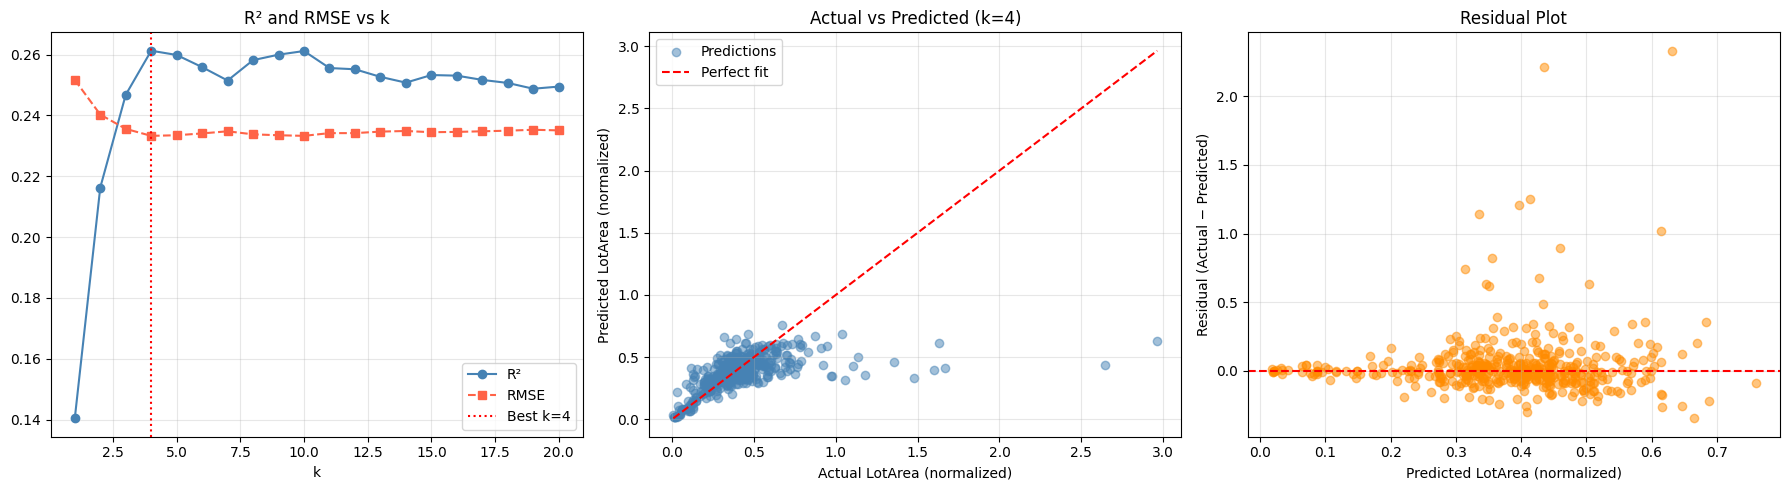

In [28]:
# KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

results = []
for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(df_model, y)
    y_pred = knn.predict(df_test_model)
    results.append({
        'k'   : k,
        'R2'  : round(r2_score(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE' : round(mean_absolute_error(y_test, y_pred), 4),
        'MAPE': round(mean_absolute_percentage_error(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results)
print("\nKNN Results (trained on full train.csv, evaluated on test.csv):")
display(results_df)

best_k = int(results_df.loc[results_df['R2'].idxmax(), 'k'])
best   = results_df.loc[results_df['k'] == best_k].iloc[0]
print(f"\nBest k={best_k}  R²={best['R2']:.4f}  RMSE={best['RMSE']:.4f}  MAE={best['MAE']:.4f}  MAPE={best['MAPE']:.4f}")

# ── Step 3: plots for best k ──────────────────────────────────────────────────
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(df_model, y)
y_pred_best = knn_best.predict(df_test_model)
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow plot
axes[0].plot(results_df['k'], results_df['R2'],   'o-', color='steelblue', label='R²')
axes[0].plot(results_df['k'], results_df['RMSE'], 's--', color='tomato',   label='RMSE')
axes[0].axvline(best_k, color='red', linestyle=':', label=f'Best k={best_k}')
axes[0].set_xlabel('k'); axes[0].set_title('R² and RMSE vs k')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Actual vs predicted
axes[1].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', label='Predictions')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
axes[1].set_xlabel("Actual LotArea (normalized)")
axes[1].set_ylabel("Predicted LotArea (normalized)")
axes[1].set_title(f"Actual vs Predicted (k={best_k})")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Residual plot
axes[2].scatter(y_pred_best, residuals, alpha=0.5, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel("Predicted LotArea (normalized)")
axes[2].set_ylabel("Residual (Actual − Predicted)")
axes[2].set_title("Residual Plot")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()